In [1]:
%pip install torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import torch

In [3]:
BASE_DIR = Path.cwd().parent

ARTIFACTS_DIR = BASE_DIR / "artifacts"
DATA_DIR = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "models"

VAL_PATH = DATA_DIR / "processed" / "validation.csv"
TEST_PATH = DATA_DIR / "processed" / "test.csv"

XGB_PATH = ARTIFACTS_DIR / "xgboost_model.pkl"
AUTOENCODER_PATH = MODELS_DIR / "autoencoder.pth"

META_MODEL_PATH = ARTIFACTS_DIR / "meta_model.pkl"

TARGET = "Class"

print("Project root:", BASE_DIR)
print("XGBoost:", XGB_PATH)
print("Autoencoder:", AUTOENCODER_PATH)



Project root: d:\Summer\Summer 26\Tech Master\Final Project\AI-Fraud-Detection-System
XGBoost: d:\Summer\Summer 26\Tech Master\Final Project\AI-Fraud-Detection-System\artifacts\xgboost_model.pkl
Autoencoder: d:\Summer\Summer 26\Tech Master\Final Project\AI-Fraud-Detection-System\models\autoencoder.pth


In [4]:
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

display(val_df.head())

Validation shape: (42559, 34)
Test shape: (42559, 34)


,Time,Amount,Amount_log,V1,V2,V3,V4,V5,V6,V7,...,V22,V23,V24,V25,V26,V27,V28,Hour_cos,Hour_sin,Class
0,-0.348493,-0.026980,0.760476,-6.710910,4.279655,-3.108513,-1.293744,-3.881541,-1.467701,-1.855146,...,-0.715693,0.475927,0.591831,0.217663,0.686563,0.130771,-0.069925,0.707107,-0.707107,0
1,-0.990670,-0.256775,0.085922,1.200216,0.118330,0.563590,0.817746,0.013174,0.616752,-0.397075,...,0.041513,-0.186054,-1.014588,0.517047,-0.372589,0.054376,0.021428,-0.965926,-0.258819,0
2,0.700357,-0.158421,0.467146,-1.350348,1.444447,2.677360,4.720120,-0.724403,2.990399,-1.814565,...,-0.059087,0.119699,-0.545527,-0.314678,0.612277,0.547775,0.152983,-0.965926,0.258819,0
3,-0.735109,4.573490,2.373313,-2.651959,-3.963800,-0.533208,-1.865053,-3.167268,1.635868,3.790106,...,-0.341175,2.347637,-1.015883,1.285157,-0.126334,-0.408674,0.119461,-0.500000,-0.866025,0
4,-0.871917,-0.298402,-0.195569,1.449281,-0.936518,0.568020,-1.299196,-1.459116,-0.729640,-0.923614,...,0.014594,0.093004,0.398582,0.296354,-0.199576,0.051573,0.022946,-0.866025,-0.500000,0


In [5]:
X_val = val_df.drop(columns=[TARGET])
y_val = val_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_val: (42559, 33)
X_test: (42559, 33)
y_val: (42559,)
y_test: (42559,)


In [6]:
xgb_model = joblib.load(XGB_PATH)

print("XGBoost loaded successfully!")
print(type(xgb_model))

XGBoost loaded successfully!
<class 'xgboost.sklearn.XGBClassifier'>


In [7]:
print("Number of features:", xgb_model.n_features_in_)
print("Expected features:", X_val.shape[1])

Number of features: 33
Expected features: 33


In [8]:
ml_val_proba = xgb_model.predict_proba(X_val)[:, 1]
ml_test_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Validation ML probabilities:")
print(ml_val_proba[:10])

print("\nTest ML probabilities:")
print(ml_test_proba[:10])

Validation ML probabilities:
[5.1212169e-07 6.0680140e-06 2.0234493e-05 3.9885899e-06 4.1226208e-06
 5.3024110e-06 1.3855367e-04 1.5602292e-05 1.3064466e-04 1.3734149e-06]

Test ML probabilities:
[7.78821704e-05 1.73136823e-06 8.61367596e-07 1.30745475e-05
 5.85110138e-06 1.73113563e-06 8.82691438e-06 5.63150797e-06
 9.87832609e-05 7.13065765e-06]


In [9]:
import sys
sys.path.insert(0, str(BASE_DIR / "src"))

from dl_pipeline import load_autoencoder, calculate_anomaly_score

In [10]:
autoencoder, ae_threshold, device = load_autoencoder(
    AUTOENCODER_PATH
)

print("Autoencoder loaded successfully!")
print("Device:", device)
print("Autoencoder threshold:", ae_threshold)

Autoencoder loaded successfully!
Device: cpu
Autoencoder threshold: 3.7661664581299585


In [11]:
dl_val_scores = calculate_anomaly_score(
    autoencoder,
    X_val.to_numpy(dtype=np.float32),
    device
)

dl_test_scores = calculate_anomaly_score(
    autoencoder,
    X_test.to_numpy(dtype=np.float32),
    device
)

print("Validation anomaly scores:")
print(dl_val_scores[:10])

print("\nTest anomaly scores:")
print(dl_test_scores[:10])

Validation anomaly scores:
[0.20578724 0.17807561 0.20034869 0.43087474 0.0770513  0.08059461
 0.4075997  0.4588112  0.05592748 0.12000298]

Test anomaly scores:
[0.12661143 0.14534596 0.15659332 0.07443527 0.05456999 0.51236725
 0.06696048 0.14440957 0.05425748 0.06894691]


In [12]:
#Inspect the two signals
signals_val = pd.DataFrame({
    "fraud_probability": ml_val_proba,
    "anomaly_score": dl_val_scores,
    "target": y_val.to_numpy()
})

signals_test = pd.DataFrame({
    "fraud_probability": ml_test_proba,
    "anomaly_score": dl_test_scores,
    "target": y_test.to_numpy()
})

display(signals_val.head())
display(signals_val.describe())

,fraud_probability,anomaly_score,target
0,5.121217e-07,0.205787,0
1,6.068014e-06,0.178076,0
2,2.023449e-05,0.200349,0
3,3.988590e-06,0.430875,0
4,4.122621e-06,0.077051,0


,fraud_probability,anomaly_score,target
count,4.255900e+04,42559.000000,42559.000000
mean,1.688867e-03,0.189121,0.001668
std,3.856475e-02,1.158118,0.040811
min,1.051256e-08,0.011306,0.000000
25%,2.580107e-06,0.059679,0.000000
50%,6.932726e-06,0.098398,0.000000
75%,2.386020e-05,0.176172,0.000000
max,9.999979e-01,53.060844,1.000000


In [13]:
# Normalize anomaly score using META-TRAINING data only
# We keep a separate threshold-validation split so the final test set is untouched.

meta_train_idx, threshold_val_idx = train_test_split(
    np.arange(len(y_val)),
    test_size=0.30,
    stratify=y_val,
    random_state=42
)

dl_meta_train = dl_val_scores[meta_train_idx]
dl_threshold_val = dl_val_scores[threshold_val_idx]

anomaly_scaler = MinMaxScaler()

dl_meta_train_normalized = anomaly_scaler.fit_transform(
    dl_meta_train.reshape(-1, 1)
).ravel()

dl_threshold_val_normalized = anomaly_scaler.transform(
    dl_threshold_val.reshape(-1, 1)
).ravel()

dl_test_normalized = anomaly_scaler.transform(
    dl_test_scores.reshape(-1, 1)
).ravel()

print("Meta-train samples:", len(meta_train_idx))
print("Threshold-validation samples:", len(threshold_val_idx))
print("Test samples:", len(y_test))
print("Meta-train anomaly range:", dl_meta_train_normalized.min(), dl_meta_train_normalized.max())
print("Threshold-validation anomaly range:", dl_threshold_val_normalized.min(), dl_threshold_val_normalized.max())
print("Test anomaly range:", dl_test_normalized.min(), dl_test_normalized.max())


Meta-train samples: 29791
Threshold-validation samples: 12768
Test samples: 42559
Meta-train anomaly range: 0.0 1.0
Threshold-validation anomaly range: 4.1824504e-05 0.9636317
Test anomaly range: 3.8936676e-05 2.2753851


In [14]:
# Create Hybrid Features
X_meta_train = pd.DataFrame({
    "fraud_probability": ml_val_proba[meta_train_idx],
    "anomaly_score": dl_meta_train_normalized
})

y_meta_train = y_val.iloc[meta_train_idx].reset_index(drop=True)

X_threshold_val = pd.DataFrame({
    "fraud_probability": ml_val_proba[threshold_val_idx],
    "anomaly_score": dl_threshold_val_normalized
})

y_threshold_val = y_val.iloc[threshold_val_idx].reset_index(drop=True)

X_meta_test = pd.DataFrame({
    "fraud_probability": ml_test_proba,
    "anomaly_score": dl_test_normalized
})

display(X_meta_train.head())
print("Meta-train shape:", X_meta_train.shape)
print("Threshold-validation shape:", X_threshold_val.shape)
print("Test shape:", X_meta_test.shape)


,fraud_probability,anomaly_score
0,0.000002,0.000997
1,0.000110,0.000471
2,0.000002,0.003940
3,0.000079,0.002761
4,0.000011,0.005314


Meta-train shape: (29791, 2)
Threshold-validation shape: (12768, 2)
Test shape: (42559, 2)


In [15]:
# Train Meta-Learner
# The meta-learner is trained only on the meta-training portion of validation.
# The threshold is selected later on a separate threshold-validation portion.

meta_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

meta_model.fit(X_meta_train, y_meta_train)

print("Meta-learner trained successfully!")
print("Meta coefficients:", dict(zip(X_meta_train.columns, meta_model.coef_[0])))


Meta-learner trained successfully!
Meta coefficients: {'fraud_probability': np.float64(13.324646490068597), 'anomaly_score': np.float64(5.944480361825993)}


In [16]:
# Generate Final Fraud Scores
# Test data is used only for final evaluation after the model and threshold are fixed.

final_threshold_val_scores = meta_model.predict_proba(X_threshold_val)[:, 1]
final_test_scores = meta_model.predict_proba(X_meta_test)[:, 1]

print("Threshold-validation final scores:", final_threshold_val_scores[:10])
print("Test final scores:", final_test_scores[:10])


Threshold-validation final scores: [0.12640601 0.12416856 0.12454518 0.1248946  0.12426681 0.1249406
 0.12648188 0.12662191 0.12425032 0.12419124]
Test final scores: [0.12522519 0.12534406 0.12548102 0.12449199 0.12423909 0.1299228
 0.12439456 0.12533825 0.12437007 0.12441634]


In [17]:
# Evaluate the Hybrid Model
threshold_val_pr_auc = average_precision_score(
    y_threshold_val,
    final_threshold_val_scores
)

test_pr_auc = average_precision_score(
    y_test,
    final_test_scores
)

test_roc_auc = roc_auc_score(
    y_test,
    final_test_scores
)

print("Threshold-validation PR-AUC:", threshold_val_pr_auc)
print("Test PR-AUC:", test_pr_auc)
print("Test ROC-AUC:", test_roc_auc)


Threshold-validation PR-AUC: 0.8596784288089782
Test PR-AUC: 0.768872337491097
Test ROC-AUC: 0.954268777795752


In [18]:
# Find Threshold on a dedicated validation subset
# The final test set is NOT used to choose the threshold.

thresholds = np.arange(0.10, 0.91, 0.01)
threshold_results = []

for threshold in thresholds:
    predictions = (final_threshold_val_scores >= threshold).astype(int)

    precision = precision_score(
        y_threshold_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_threshold_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_threshold_val,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.sort_values(
        "f1",
        ascending=False
    ).head(10)
)


,threshold,precision,recall,f1
20,0.30,0.655172,0.904762,0.76
25,0.35,0.655172,0.904762,0.76
26,0.36,0.655172,0.904762,0.76
24,0.34,0.655172,0.904762,0.76
23,0.33,0.655172,0.904762,0.76
21,0.31,0.655172,0.904762,0.76
22,0.32,0.655172,0.904762,0.76
28,0.38,0.655172,0.904762,0.76
27,0.37,0.655172,0.904762,0.76
19,0.29,0.655172,0.904762,0.76


In [19]:
best_threshold = float(
    threshold_df.loc[
        threshold_df["f1"].idxmax(),
        "threshold"
    ]
)

print("Selected threshold:", best_threshold)
print("Threshold selected using threshold-validation data only.")


Selected threshold: 0.2899999999999999
Threshold selected using threshold-validation data only.


In [20]:
# Final Test Evaluation
# IMPORTANT: this is the first time the final test labels are used for classification metrics.

test_predictions = (
    final_test_scores >= best_threshold
).astype(int)

test_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

print("Test PR-AUC:", test_pr_auc)
print("Test ROC-AUC:", test_roc_auc)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1:", test_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)


Test PR-AUC: 0.768872337491097
Test ROC-AUC: 0.954268777795752
Test Precision: 0.6555555555555556
Test Recall: 0.8309859154929577
Test F1: 0.7329192546583851

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42488
       Fraud       0.66      0.83      0.73        71

    accuracy                           1.00     42559
   macro avg       0.83      0.92      0.87     42559
weighted avg       1.00      1.00      1.00     42559



In [21]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    test_predictions
)

print(cm)

[[42457    31]
 [   12    59]]


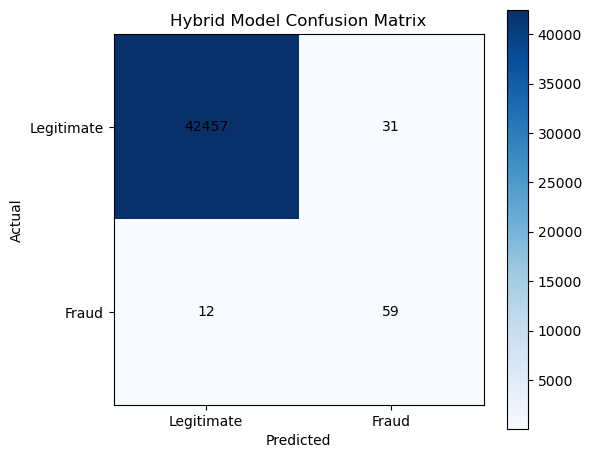

In [22]:
plt.figure(figsize=(6, 5))

plt.imshow(cm, cmap="Blues")

plt.title("Hybrid Model Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.yticks([0, 1], ["Legitimate", "Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()

plt.tight_layout()
plt.show()

In [23]:
#Save Meta-Learner
joblib.dump(
    meta_model,
    META_MODEL_PATH
)

print(f"Saved to: {META_MODEL_PATH}")

Saved to: d:\Summer\Summer 26\Tech Master\Final Project\AI-Fraud-Detection-System\artifacts\meta_model.pkl


In [24]:
# Hybrid Results Summary
results = pd.DataFrame({
    "metric": [
        "PR-AUC",
        "ROC-AUC",
        "Precision",
        "Recall",
        "F1",
        "Threshold"
    ],
    "value": [
        test_pr_auc,
        test_roc_auc,
        test_precision,
        test_recall,
        test_f1,
        best_threshold
    ]
})

display(results)


,metric,value
0,PR-AUC,0.768872
1,ROC-AUC,0.954269
2,Precision,0.655556
3,Recall,0.830986
4,F1,0.732919
5,Threshold,0.290000


In [25]:
joblib.dump(
    anomaly_scaler,
    ARTIFACTS_DIR / "anomaly_scaler.pkl"
)

print("Anomaly scaler saved successfully!")

Anomaly scaler saved successfully!


In [26]:
with open(ARTIFACTS_DIR / "hybrid_config.json", "w") as f:
    json.dump(
        {
            "threshold": float(best_threshold),
            "meta_features": [
                "fraud_probability",
                "anomaly_score"
            ],
            "threshold_selection": "F1 maximization on a held-out validation subset",
            "random_state": 42
        },
        f,
        indent=4
    )

print(f"Saved hybrid configuration to: {ARTIFACTS_DIR / 'hybrid_config.json'}")


Saved hybrid configuration to: d:\Summer\Summer 26\Tech Master\Final Project\AI-Fraud-Detection-System\artifacts\hybrid_config.json


Shap

In [27]:
%pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [28]:
import shap

In [29]:
# Create SHAP Explainer
# SHAP is used only for transactions classified as Fraud by the final hybrid system.
explainer = shap.TreeExplainer(xgb_model)

print("SHAP explainer created for XGBoost.")


SHAP explainer created for XGBoost.


In [30]:
# Select FRAUD transactions only
fraud_mask = final_test_scores >= best_threshold
fraud_indices = np.flatnonzero(fraud_mask)

print("Fraud predictions on test set:", len(fraud_indices))
print("Total test transactions:", len(X_test))

if len(fraud_indices) == 0:
    print("No transactions were classified as Fraud. SHAP will be skipped.")
    X_shap = X_test.iloc[0:0]
    shap_values = np.empty((0, X_test.shape[1]))
else:
    sample_size = min(1000, len(fraud_indices))
    selected_indices = fraud_indices[:sample_size]
    X_shap = X_test.iloc[selected_indices]

    shap_values = explainer.shap_values(X_shap)

    # Handle SHAP versions that return a list for binary classification.
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]

    shap_values = np.asarray(shap_values)

    print("SHAP calculated for Fraud predictions only.")
    print("SHAP sample shape:", X_shap.shape)
    print("SHAP values shape:", shap_values.shape)


Fraud predictions on test set: 90
Total test transactions: 42559
SHAP calculated for Fraud predictions only.
SHAP sample shape: (90, 33)
SHAP values shape: (90, 33)


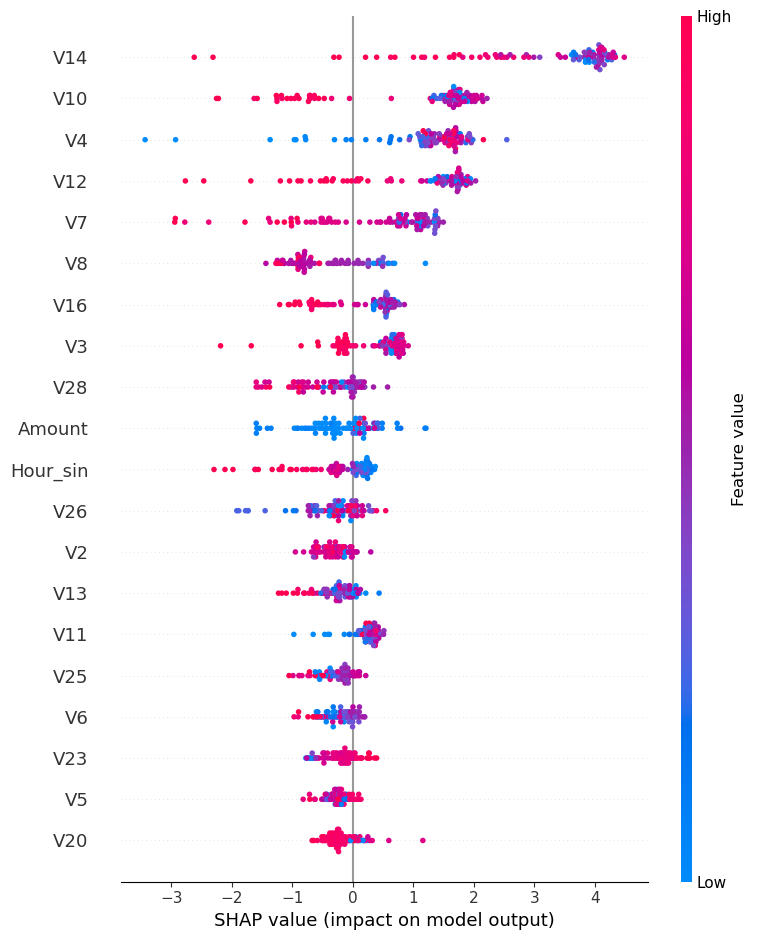

In [31]:
# Fraud-only SHAP Summary
if len(X_shap) > 0:
    shap.summary_plot(
        shap_values,
        X_shap,
        show=True
    )
else:
    print("No Fraud predictions available for SHAP summary.")


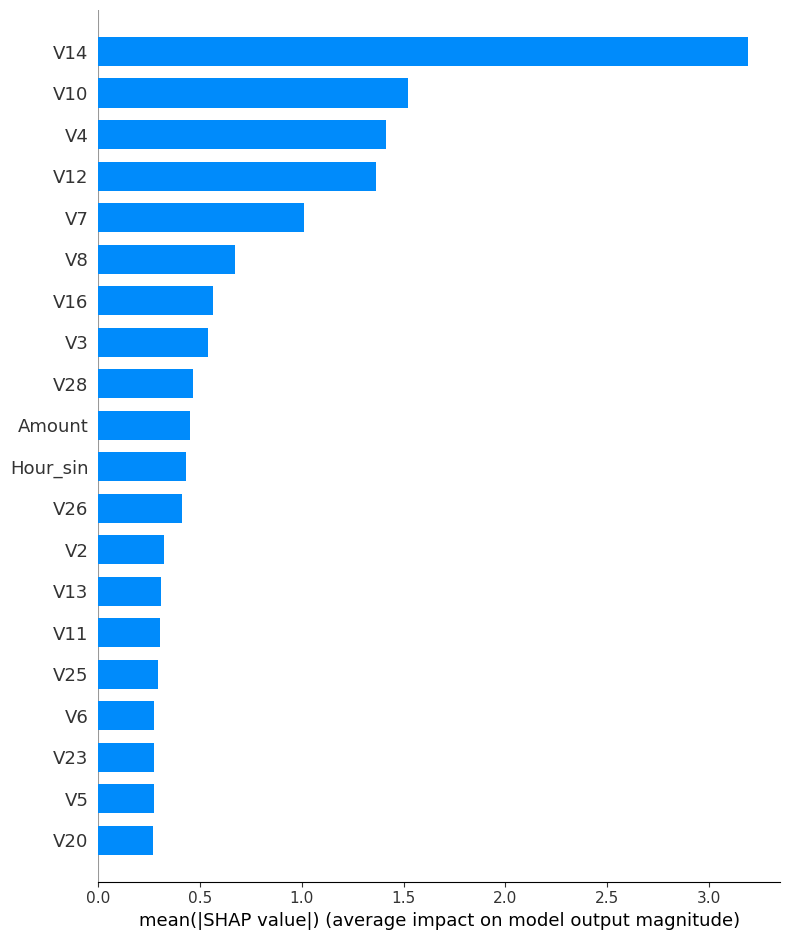

In [32]:
# Fraud-only Global Feature Importance
if len(X_shap) > 0:
    shap.summary_plot(
        shap_values,
        X_shap,
        plot_type="bar",
        show=True
    )
else:
    print("No Fraud predictions available for SHAP feature importance.")


In [33]:
# Explain One FRAUD Transaction
if len(fraud_indices) == 0:
    print("No Fraud transaction is available for a SHAP explanation.")
else:
    transaction_index = int(fraud_indices[0])
    transaction = X_test.iloc[[transaction_index]]

    transaction_shap = explainer.shap_values(transaction)

    if isinstance(transaction_shap, list):
        transaction_shap = transaction_shap[-1]

    transaction_shap = np.asarray(transaction_shap)

    print("Transaction index:", transaction_index)
    print("ML fraud probability:", ml_test_proba[transaction_index])
    print("Final fraud score:", final_test_scores[transaction_index])
    print("Status: Fraud")


Transaction index: 168
ML fraud probability: 0.99993956
Final fraud score: 0.9999960004613323
Status: Fraud


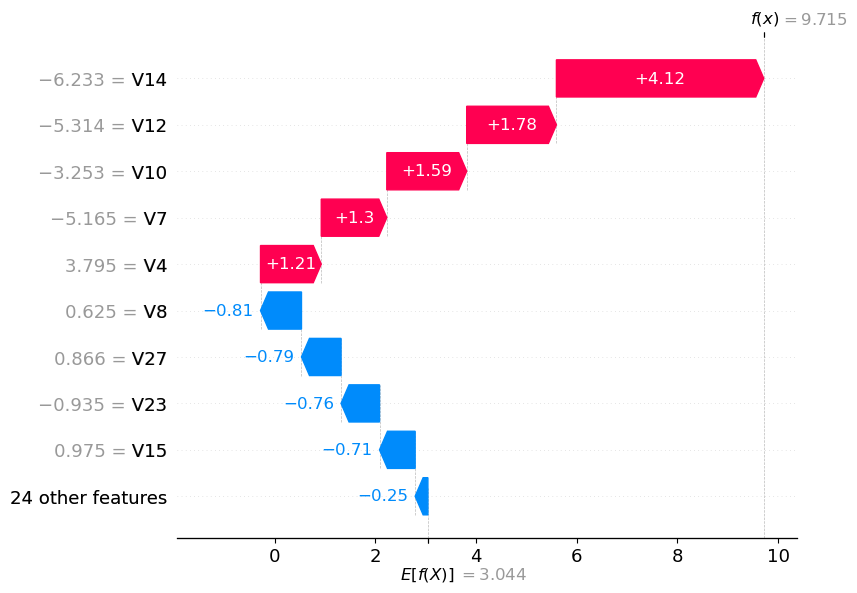

In [34]:
# Waterfall Explanation for a FRAUD Transaction
if len(fraud_indices) > 0:
    transaction_explanation = shap.Explanation(
        values=transaction_shap[0],
        base_values=explainer.expected_value[-1]
        if isinstance(explainer.expected_value, (list, np.ndarray))
        else explainer.expected_value,
        data=transaction.iloc[0].values,
        feature_names=transaction.columns.tolist()
    )

    shap.plots.waterfall(
        transaction_explanation,
        max_display=10,
        show=True
    )
else:
    print("Waterfall explanation skipped because there are no Fraud predictions.")


In [35]:
# Top SHAP Features among FRAUD predictions only
if len(X_shap) > 0:
    feature_importance = pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    }).sort_values(
        "mean_abs_shap",
        ascending=False
    )

    display(feature_importance.head(15))
else:
    feature_importance = pd.DataFrame(
        columns=["feature", "mean_abs_shap"]
    )
    print("No Fraud predictions available for feature importance.")


,feature,mean_abs_shap
16,V14,3.188913
12,V10,1.522406
6,V4,1.414659
14,V12,1.363682
9,V7,1.008695
10,V8,0.669469
18,V16,0.562628
5,V3,0.537595
30,V28,0.464777
1,Amount,0.448394


In [36]:
# Save Fraud-only SHAP Results
reports_dir = BASE_DIR / "reports"
reports_dir.mkdir(
    parents=True,
    exist_ok=True
)

feature_importance.to_csv(
    reports_dir / "shap_feature_importance_fraud_only.csv",
    index=False
)

print(
    f"Saved Fraud-only SHAP results to: "
    f"{reports_dir / 'shap_feature_importance_fraud_only.csv'}"
)


Saved Fraud-only SHAP results to: d:\Summer\Summer 26\Tech Master\Final Project\AI-Fraud-Detection-System\reports\shap_feature_importance_fraud_only.csv


In [37]:
# Final sanity checks
print("Hybrid model finalization checks:")
print("✓ Meta-learner trained without using final test labels")
print("✓ Threshold selected without using final test labels")
print("✓ Final test used only for final evaluation")
print("✓ SHAP generated only for transactions classified as Fraud")
print("✓ Meta model saved")
print("✓ Anomaly scaler saved")
print("✓ Hybrid configuration saved")


Hybrid model finalization checks:
✓ Meta-learner trained without using final test labels
✓ Threshold selected without using final test labels
✓ Final test used only for final evaluation
✓ SHAP generated only for transactions classified as Fraud
✓ Meta model saved
✓ Anomaly scaler saved
✓ Hybrid configuration saved
